In [10]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
from utils.utils import load_data, split_db_2to1, vcol, vrow
from utils.BinaryLR import BinaryLR
import matplotlib.pyplot as plt

In [11]:
PROJECT_FILE = "../data/trainData.txt"
D, L, labels = load_data(PROJECT_FILE)
feature_names = [f'F{i}' for i in range(0, D.shape[0])]
L = L.astype(int)
labels = [0, 1]
(DTR, LTR), (DTE, LTE) = split_db_2to1(D, L)

# Logistic Regression

In [12]:
model = BinaryLR(pi1=0.1)

In [13]:
lamb = np.logspace(-4, 2, 13)

## All data

In [14]:

DCFs = np.zeros(len(lamb))
minDCFs = np.zeros(len(lamb))
for i, l in enumerate(lamb):
    model.set_lambda(l)
    model.fit(DTR, LTR)
    pred = model.predict(DTE)
    DCF = model.evaluate(LTE)[3]
    minDCF = model.calc_minDCF(LTE)
    DCFs[i] = DCF
    minDCFs[i] = minDCF


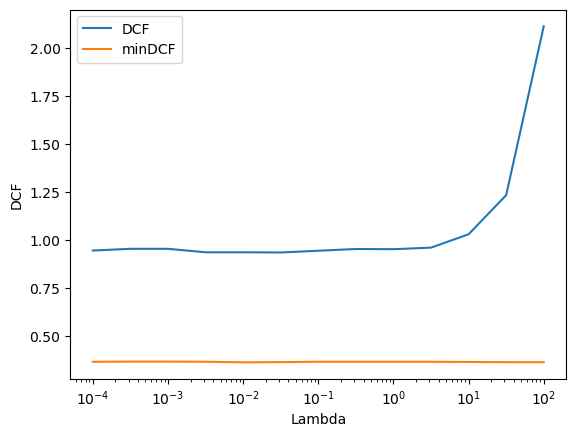

In [15]:
plt.plot(lamb, DCFs, label='DCF')
plt.plot(lamb, minDCFs, label='minDCF')
plt.xscale('log', base=10)
plt.xlabel('Lambda')
plt.ylabel('DCF')
plt.legend()
plt.show()

## Partial Data

In [16]:

DCFs = np.zeros(len(lamb))
minDCFs = np.zeros(len(lamb))
for i, l in enumerate(lamb):
    model.set_lambda(l)
    model.fit(DTR[:, ::50], LTR[::50])
    pred = model.predict(DTE)
    DCF = model.evaluate(LTE)[3]
    minDCF = model.calc_minDCF(LTE)
    DCFs[i] = DCF
    minDCFs[i] = minDCF


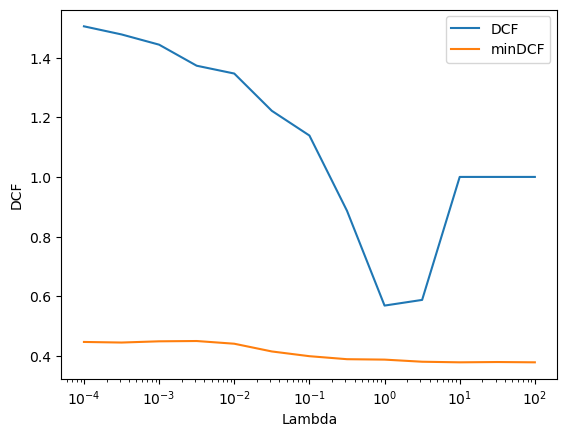

In [17]:
plt.plot(lamb, DCFs, label='DCF')
plt.plot(lamb, minDCFs, label='minDCF')
plt.xscale('log', base=10)
plt.xlabel('Lambda')
plt.ylabel('DCF')
plt.legend()
plt.show()

## Prior weighted

In [18]:

DCFs = np.zeros(len(lamb))
minDCFs = np.zeros(len(lamb))
for i, l in enumerate(lamb):
    model.set_lambda(l)
    model.fit(DTR, LTR, prior_weighted=True)
    pred = model.predict(DTE)
    DCF = model.evaluate(LTE)[3]
    minDCF = model.calc_minDCF(LTE)
    DCFs[i] = DCF
    minDCFs[i] = minDCF


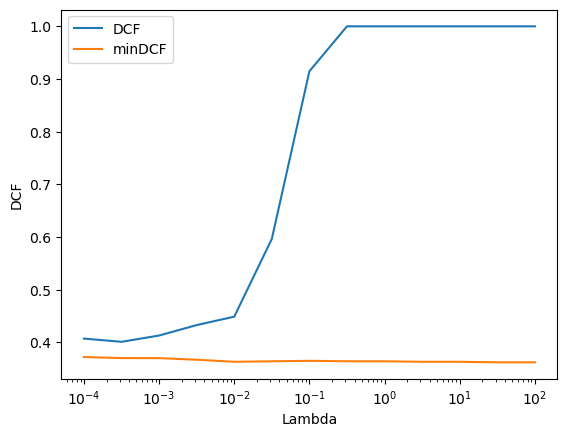

In [19]:
plt.plot(lamb, DCFs, label='DCF')
plt.plot(lamb, minDCFs, label='minDCF')
plt.xscale('log', base=10)
plt.xlabel('Lambda')
plt.ylabel('DCF')
plt.legend()
plt.show()

## Quadratic

In [23]:
# DTR shape: (D, N)
D, N = DTR.shape
quad_DTR = np.einsum('dn,en->den', DTR, DTR).reshape(D*D, N)  # (D², N)
quadratic_DTR = np.vstack((quad_DTR, DTR))                      # (D²+D, N)

quad_DTE = np.einsum('dn,en->den', DTE, DTE).reshape(D*D, DTE.shape[1])
quadratic_DTE = np.vstack((quad_DTE, DTE))


In [24]:
DCFs = np.zeros(len(lamb))
minDCFs = np.zeros(len(lamb))

for i, l in enumerate(lamb):
    model.set_lambda(l)
    model.fit(quadratic_DTR, LTR, prior_weighted=True)
    pred = model.predict(quadratic_DTE)
    DCF = model.evaluate(LTE)[3]
    minDCF = model.calc_minDCF(LTE)
    DCFs[i] = DCF
    minDCFs[i] = minDCF


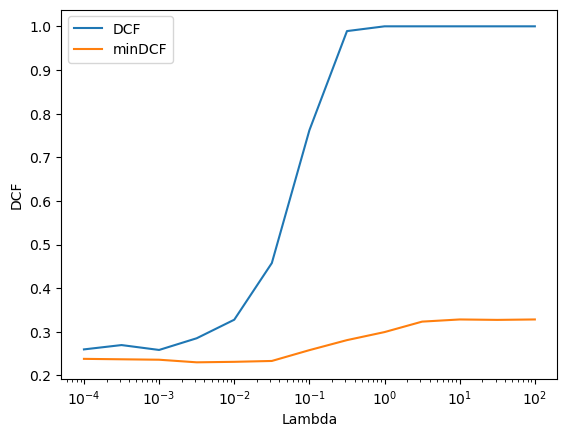

In [25]:
plt.plot(lamb, DCFs, label='DCF')
plt.plot(lamb, minDCFs, label='minDCF')
plt.xscale('log', base=10)
plt.xlabel('Lambda')
plt.ylabel('DCF')
plt.legend()
plt.show()